## Analysis of monthly average CO2 concentration data

### 0. Data inputs and cleaning

The .xlsx file was converted to .csv file for easier Python processing. Read the data and check that there are no NAN values in the data.

Number of NANs:  0
Shape of the Data:  (813, 2)


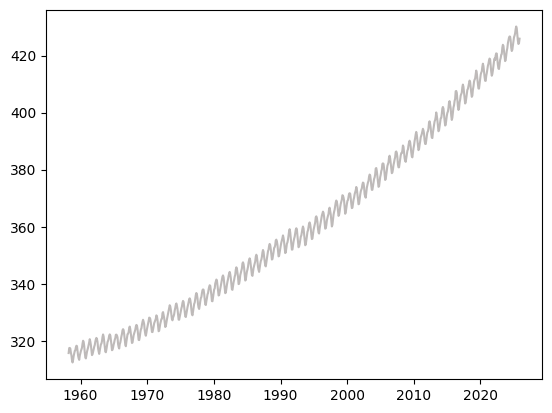

In [100]:
import matplotlib.pyplot as plt
import numpy as np

data = np.loadtxt("Mauna_Loa_Monthly_CO2_Data.csv", delimiter=',', skiprows=3)
print("Number of NANs: ", np.sum(np.isnan(data)))
print("Shape of the Data: ", data.shape)

plt.plot(data[:, 0], data[:, 1], c = '#BEBAB9')
plt.show()

### 1. Designing a general filter solver.

First, consider a symmetrical filter with an odd M:
$$h_{(\frac{M-1}{2}+n)}=h_{(\frac{M-1}{2}-n)}$$

Then perform a fourier transform on the filter:
$$H_k = \sum_{m=0}^{M-1} h_m e^{-ikm}\\=e^{-ik\frac{M-1}{2}}\left[h_{\frac{M-1}{2}}+\sum_{m=0}^{(M-3)/2} 2 h_m \cos{\left(k\left(\frac{M-1}{2}-m\right)\right)}\right]$$

The frequency responce vector:
$$H_r(k)=a_0 h_0 + a_1 h_1 + \cdots + a_{\frac{M-3}{2}} h_{\frac{M-3}{2}} + h_{\frac{M-1}{2}} a_{\frac{M-1}{2}}$$
where $a_n(k)=2\cos{\left[k\left(\frac{M-1}{2}-n\right)\right]}$

With a set of the linear equations, a matrix form of dimensions $(\mu+1)\times(\mu+1)=\frac{M+1}{2}\times \frac{M+1}{2}$ can be constructed as:
$$
A \left(
    \begin{array}{ccc}
        h_0 & h_1 & \cdots & h_{\mu}
    \end{array}
\right)^T = 
\left(
    \begin{array}{ccc}
        H_0^r & H_1^r & \cdots & H_{\mu}^r
    \end{array}
\right)^T
$$

where $a_{mn}=2\cos\left[\frac{2\pi m}{M}\left(\frac{M-1}{2}-n\right)\right]$

Then we can set the $H_i^r$ with filter conditions and solve $h_i$ out of the matrix equation.

In [101]:
def solve_filter(M = 65, Hr = None):
    mu = (M - 1) // 2
    A = np.zeros((mu + 1, mu + 1))

    # Construct the coefficients matrix
    for i in range(mu + 1):
        km = 2 * np.pi * i / M
        for j in range(mu):
            s = j
            A[i, j] = 2 * np.cos(km * (mu - s))
        A[i, mu] = 1

    # Solve linear equation, get half of the filter 
    h_half = np.linalg.solve(A, Hr)
    # Fill in the other half
    h = np.concatenate([h_half[:-1], [h_half[-1]], h_half[:-1][::-1]])

    return h

Now we can construct a `Hr` vector to solve the corresponding `h` vector.

In [102]:
def create_target_response(M, type='lowpass', cutoffs=None, transition_width=0):
    mu = (M - 1) // 2
    freqs = np.linspace(0, 0.5, mu + 1)
    Hr = np.zeros(mu + 1)

    # Add smoothing to the cutoffs
    def apply_smoothing(response, center_freq, width, direction='down'):
        if width <= 0:
            return response
        idx = np.where(np.abs(freqs - center_freq) < width / 2)[0]
        for i in idx:
            dis = (freqs[i] - (center_freq - width / 2)) / width
            if direction == 'down':
                response[i] = 0.5 * (1 + np.cos(np.pi * dis))
            elif direction == 'up':
                response[i] = 0.5 * (1 - np.cos(np.pi * dis))
        return response

    if type == 'lowpass':
        fc = cutoffs[0]
        Hr[freqs < fc] = 1
        apply_smoothing(Hr, fc, transition_width, 'down')
    elif type == 'highpass':
        fc = cutoffs[0]
        Hr[freqs > fc] = 1
        apply_smoothing(Hr, fc, transition_width, 'up')
    elif type == 'bandpass':
        f_low, f_high = cutoffs
        Hr[(freqs >= f_low) & (freqs <= f_high)] = 1
        apply_smoothing(Hr, f_low, transition_width, 'up')
        apply_smoothing(Hr, f_high, transition_width, 'down')
    
    return Hr

## (a). Design a low-pass filter with a threshold at 24-month cycle. Apply the filter to the data.

In [103]:
# Create a low-pass filter of length 5 * 24 + 1 = 121
Hr_low_pass_24 = create_target_response(M=121, type='lowpass', cutoffs=[1 / 24], transition_width=3 / 121)
h_low_pass_24 = solve_filter(M=121, Hr = Hr_low_pass_24)

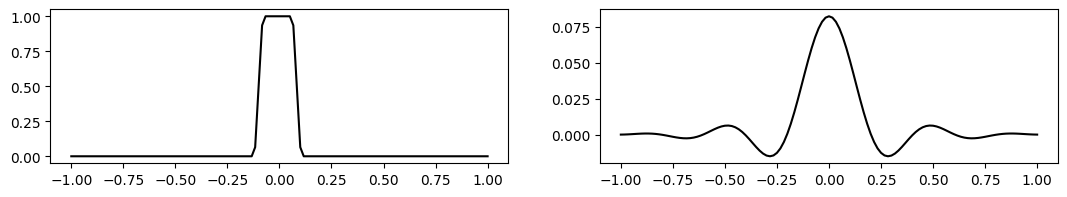

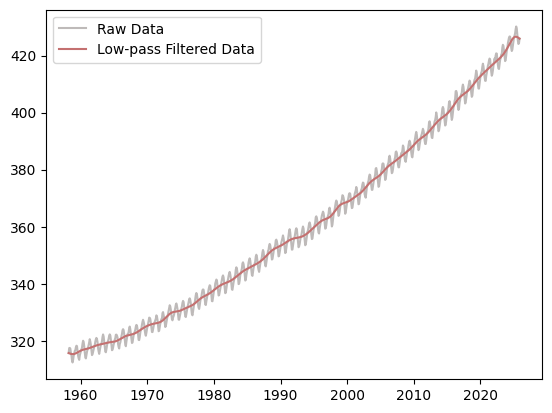

In [104]:
plt.figure(figsize=(13, 2))
plt.subplot(1, 2, 1)
plt.plot(np.linspace(-1, 1, 121), np.concatenate([Hr_low_pass_24[:-1][::-1], Hr_low_pass_24]), 'k')
plt.subplot(1, 2, 2)
plt.plot(np.linspace(-1, 1, 121), h_low_pass_24, 'k')
plt.show()

from scipy import signal
# Apply the filter to the data
data_lowpass = signal.filtfilt(h_low_pass_24, [1.0], data[:, 1])
plt.plot(data[:, 0], data[:, 1], c = '#BEBAB9', label='Raw Data')
plt.plot(data[:, 0], data_lowpass, c = '#C47070', label='Low-pass Filtered Data')
plt.legend()
plt.show()

## (b). Estimate the rate of change in CO2 concentration at around 1970, 1980, 1990, 2000, 2010 and 2020 on the filtered data.

Take the second half of the previous year and the first half of the year to calculate the rate of change.
$$\text{Rate}\approx \frac{\text{Trend}(1970.5)-\text{Trend}(1969.5)}{1 \text{ year}}$$

In [105]:
target = [1970, 1980, 1990, 2000, 2010, 2020]
for year in target:
    idx = np.where((data[:, 0] == year + 0.0411) | (data[:, 0] == year + 0.041))[0]
    print("Rate of change around " + str(year) + ": " + str((data_lowpass[idx+6] - data_lowpass[idx-6])[0]))

Rate of change around 1970: 1.0720224627305583
Rate of change around 1980: 1.8422069221165316
Rate of change around 1990: 1.2680922674944668
Rate of change around 2000: 1.0581492689613583
Rate of change around 2010: 2.4798452799000756
Rate of change around 2020: 2.4291885176154437


## (c). Subtract the trend obtained above from the raw data to obtain the fluctuating components. Show that the flucuating components consists mainly of annual and semi-annual cycles.

First simply subtract the trend from the raw data. To analysis the components, perform a fourier transform to find the frequencies of the fluctuations.

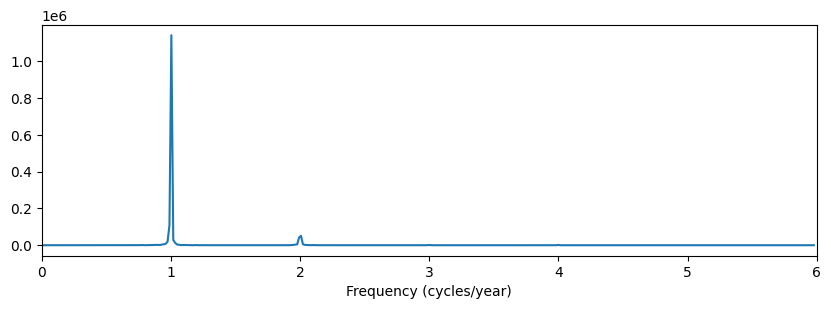

In [106]:
# Subtract the trend from the raw data
fluctuations = data[:, 1] - data_lowpass

N = len(fluctuations)
dt = 1/12
fs = 1/dt

# Perform Fourier Transform
fft_vals = np.fft.fft(fluctuations)
fft_freqs = np.fft.fftfreq(N, dt)

# Take the power spectrum of the positive half
positive_freqs = fft_freqs[:N//2]
power_spectrum = np.abs(fft_vals[:N//2])**2

plt.figure(figsize=(10, 3))
plt.plot(positive_freqs, power_spectrum)
plt.xlim(0, 6)
plt.xlabel('Frequency (cycles/year)')
plt.show()

From the graph we can clearly see that there are only two main components of annual and semi-annual cycles, while the other parts barely have contributions.

## (d). Design a band-pass filter that retain components with period of 9 months to period of 15 months to extract the annual cycle component.

In [107]:
# Design a band-pass filter
Hr_band_pass = create_target_response(M=61, type='bandpass', cutoffs=[1 / 15, 1 / 9], transition_width=0 / 61)
h_band_pass = solve_filter(M=61, Hr=Hr_band_pass)

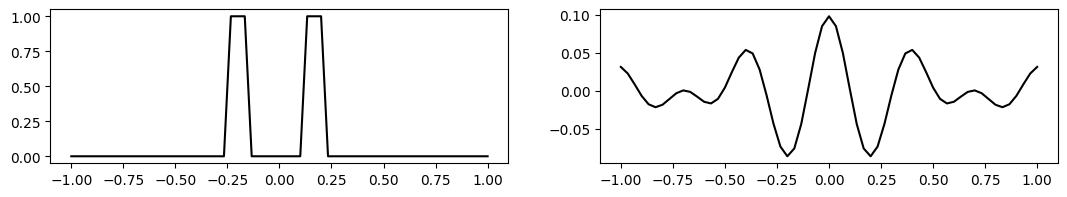

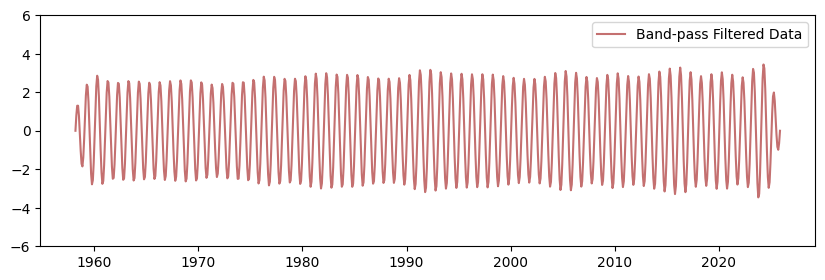

Count of Maximum Months:  [0, 0, 0, 56, 0, 0, 0, 0, 0, 0, 0, 0]
Count of Minimum Months:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 56, 0, 0]
Average annual cycle amplitude:  2.827286547349057


In [108]:
plt.figure(figsize=(13, 2))
plt.subplot(1, 2, 1)
plt.plot(np.linspace(-1, 1, 61), np.concatenate([Hr_band_pass[:-1][::-1], Hr_band_pass]), 'k')
plt.subplot(1, 2, 2)
plt.plot(np.linspace(-1, 1, 61), h_band_pass, 'k')
plt.show()

# Apply the filter to the data
data_bandpass = signal.filtfilt(h_band_pass, [1.0], data[:, 1])

plt.figure(figsize=(10, 3))
plt.plot(data[:, 0], data_bandpass, c='#C47070', label='Band-pass Filtered Data')
plt.ylim(-6, 6)
plt.legend()
plt.show()

# Calculate average annual cycle amplitude
years = 0
yearly_sum = 0
maximums = [0] * 13
minimums = [0] * 13
for i in range(70, len(data_bandpass) - 71, 12):
    maximums[np.argmax(data_bandpass[i:i+12])+1] += 1
    minimums[np.argmin(data_bandpass[i:i+12])+1] += 1
    yearly_sum += (max(data_bandpass[i:i+12]) - min(data_bandpass[i:i+12])) / 2
    years += 1
print("Count of Maximum Months: ", maximums[1:])
print("Count of Minimum Months: ", minimums[1:])
print("Average annual cycle amplitude: ", yearly_sum / years)

Counting the times that the amplitude of a month is the maximum of the minimum of the year, we see that in all 56 years under investigation, **April** has the annually maximum CO2 concentration, while **October** has the minimum.

Taking the average of amplitudes throught the years, we see an amplitude of $2.827$ of the annual cycle.

## (e). Design a high-pass filter with a cut-off threshold at 9 month cycle and apply to the data.

In [109]:
# Similar to previous steps, design a high-pass filter
Hr_high_pass_9 = create_target_response(M=61, type='highpass', cutoffs=[1 / 9], transition_width=3 / 61)
h_high_pass_9 = solve_filter(M=61, Hr=Hr_high_pass_9)

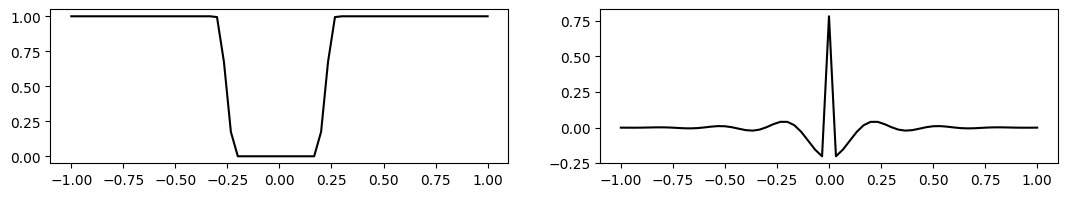

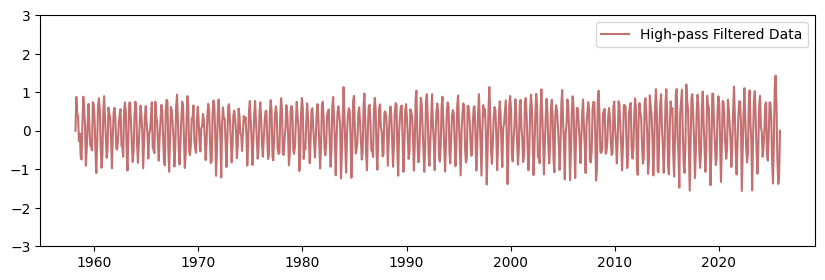

Count of Maximum Months:  [6, 0, 0, 0, 15, 91]
Count of Minimum Months:  [0, 4, 103, 5, 0, 0]
Average semi-annual cycle amplitude:  0.8562801110842194


In [110]:
plt.figure(figsize=(13, 2))
plt.subplot(1, 2, 1)
plt.plot(np.linspace(-1, 1, 61), np.concatenate([Hr_high_pass_9[:-1][::-1], Hr_high_pass_9]), 'k')
plt.subplot(1, 2, 2)
plt.plot(np.linspace(-1, 1, 61), h_high_pass_9, 'k')
plt.show()


# Apply the filter to the data
data_highpass = signal.filtfilt(h_high_pass_9, [1.0], data[:, 1])

plt.figure(figsize=(10, 3))
plt.plot(data[:, 0], data_highpass, c='#C47070', label='High-pass Filtered Data')
plt.ylim(-3, 3)
plt.legend()
plt.show()


# Calculate average annual cycle amplitude
semi_years = 0
semi_yearly_sum = 0
maximums = [0] * 7
minimums = [0] * 7
for i in range(70, len(data_highpass) - 71, 6):
    maximums[np.argmax(data_highpass[i:i+6])+1] += 1
    minimums[np.argmin(data_highpass[i:i+6])+1] += 1
    semi_yearly_sum += (max(data_highpass[i:i+6]) - min(data_highpass[i:i+6])) / 2
    semi_years += 1
print("Count of Maximum Months: ", maximums[1:])
print("Count of Minimum Months: ", minimums[1:])
print("Average semi-annual cycle amplitude: ", semi_yearly_sum / semi_years)

Doing a similar analysis for the annual cycles, we notice that for semi-annual cycles, the maximums mostly appear in **June or December**, while the minimums mostly appear in **March and September**. For the semi-annual cycle amplitude, the obtain an average of $0.856$.